In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
diabetes_ds = fetch_ucirepo(id=296) 
  
# data (as pandas dataframes) 
X = diabetes_ds.data.features 
y = diabetes_ds.data.targets 
  
# metadata 
print(diabetes_ds.metadata) 
  
# variable information 
print(diabetes_ds.variables) 


{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide pro

C:\Users\54112\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3357: DtypeWarning: Columns (10) have mixed types.Specify dtype option on import or set low_memory=False.
  if (await self.run_code(code, result,  async_=asy)):


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.concat([X, y], axis=1)

In [4]:
df.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [28]:
df[["diag_1", "diag_2", "diag_3"]].head(20)

,diag_1,diag_2,diag_3
0,250.83,NaN,NaN
1,276,250.01,255
2,648,250,V27
3,8,250.43,403
4,197,157,250
5,414,411,250
6,414,411,V45
7,428,492,250
8,398,427,38
9,434,198,486


In [5]:
print("Número de observaciones:", df.shape[0])
print("Número de variables:", df.shape[1])

Número de observaciones: 101766
Número de variables: 48


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    3197 non-null    object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                61510 non-null   object
 9   medical_specialty         51817 non-null   object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         101766 non-null  int64 
 14  numb

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
admission_type_id,101766.0,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0


In [8]:
df["readmitted"].value_counts()

NO     54864
>30    35545
<30    11357
Name: readmitted, dtype: int64

In [9]:
diabetes_ds.variables

,name,role,type,demographic,description,units,missing_values
0,encounter_id,ID,,None,Unique identifier of an encounter,None,no
1,patient_nbr,ID,,None,Unique identifier of a patient,None,no
2,race,Feature,Categorical,Race,"Values: Caucasian, Asian, African American, Hi...",None,yes
3,gender,Feature,Categorical,Gender,"Values: male, female, and unknown/invalid",None,no
4,age,Feature,Categorical,Age,"Grouped in 10-year intervals: [0, 10), [10, 20...",None,no
5,weight,Feature,Categorical,None,Weight in pounds.,None,yes
6,admission_type_id,Feature,Categorical,None,Integer identifier corresponding to 9 distinct...,None,no
7,discharge_disposition_id,Feature,Categorical,None,Integer identifier corresponding to 29 distinc...,None,no
8,admission_source_id,Feature,Categorical,None,Integer identifier corresponding to 21 distinc...,None,no
9,time_in_hospital,Feature,Integer,None,Integer number of days between admission and d...,None,no


In [10]:
missing_pct = df.isna().mean() * 100

missing_pct[missing_pct > 0].sort_values(ascending=False)

weight               96.858479
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64

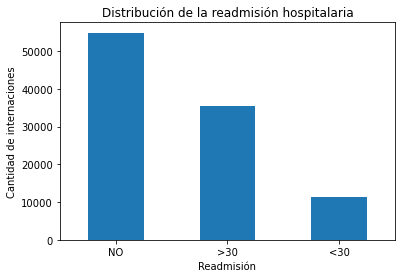

In [11]:
conteo_readmision = df["readmitted"].value_counts()

conteo_readmision.plot(kind="bar")

plt.title("Distribución de la readmisión hospitalaria")
plt.xlabel("Readmisión")
plt.ylabel("Cantidad de internaciones")
plt.xticks(rotation=0)
plt.show()

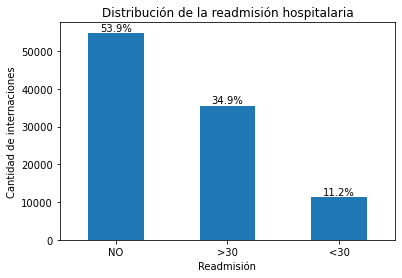

In [23]:
conteo_readmision = df["readmitted"].value_counts()
porcentaje_readmision = df["readmitted"].value_counts(normalize=True) * 100

ax = conteo_readmision.plot(kind="bar")

plt.title("Distribución de la readmisión hospitalaria")
plt.xlabel("Readmisión")
plt.ylabel("Cantidad de internaciones")
plt.xticks(rotation=0)

# Agregar porcentaje arriba de cada barra
for i, valor in enumerate(conteo_readmision):
    porcentaje = porcentaje_readmision.iloc[i]
    ax.text(
        i,
        valor,
        f"{porcentaje:.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

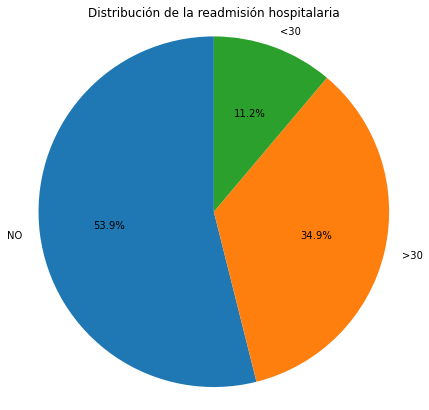

In [24]:
conteo_readmision = df["readmitted"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    conteo_readmision,
    labels=conteo_readmision.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribución de la readmisión hospitalaria")
plt.axis("equal")

plt.show()

In [12]:
print(df["readmitted"].value_counts(normalize=True) * 100)

NO     53.911916
>30    34.928169
<30    11.159916
Name: readmitted, dtype: float64


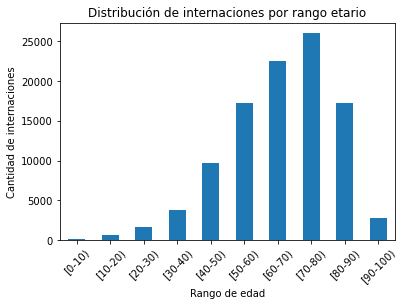

In [13]:
df["age"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribución de internaciones por rango etario")
plt.xlabel("Rango de edad")
plt.ylabel("Cantidad de internaciones")
plt.xticks(rotation=45)
plt.show()

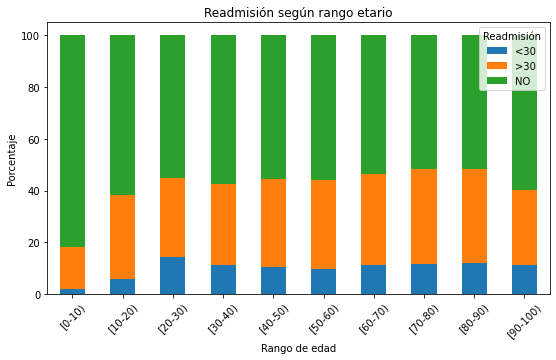

In [27]:
tabla = pd.crosstab(
    df["age"],
    df["readmitted"],
    normalize="index"
) * 100

tabla.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Readmisión según rango etario")
plt.xlabel("Rango de edad")
plt.ylabel("Porcentaje")
plt.legend(title="Readmisión")
plt.xticks(rotation=45)

plt.show()

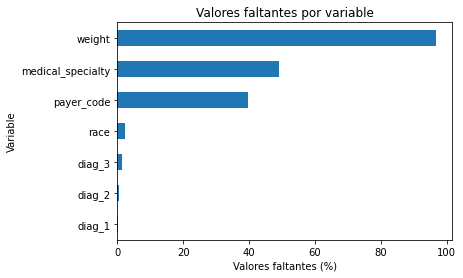

In [15]:
missing_pct = df.isna().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values()

missing_pct.plot(kind="barh")

plt.title("Valores faltantes por variable")
plt.xlabel("Valores faltantes (%)")
plt.ylabel("Variable")
plt.show()

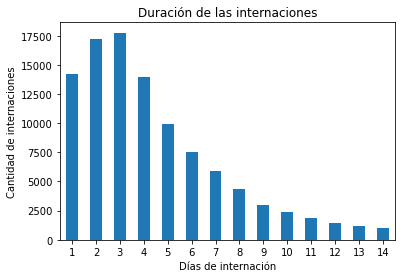

In [16]:
df["time_in_hospital"].value_counts().sort_index().plot(kind="bar")

plt.title("Duración de las internaciones")
plt.xlabel("Días de internación")
plt.ylabel("Cantidad de internaciones")
plt.xticks(rotation=0)
plt.show()

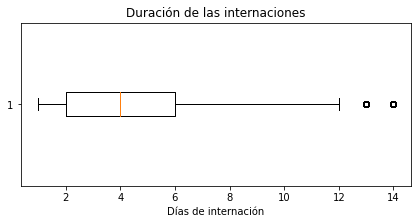

In [25]:
plt.figure(figsize=(7, 3))

plt.boxplot(df["time_in_hospital"], vert=False)

plt.title("Duración de las internaciones")
plt.xlabel("Días de internación")

plt.show()

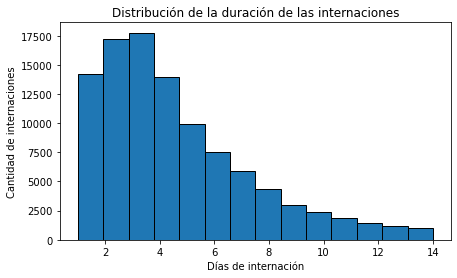

In [26]:
plt.figure(figsize=(7, 4))

plt.hist(
    df["time_in_hospital"],
    bins=14,
    edgecolor="black"
)

plt.title("Distribución de la duración de las internaciones")
plt.xlabel("Días de internación")
plt.ylabel("Cantidad de internaciones")

plt.show()